In [1]:
# imports

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import torch
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import random

In [3]:
# load data

from src.datasets_mask_crop import HAMMaskCropDataset
from src.train_effecient_mask_crop import MultiModalEfficientNet

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("../data/processed")

Using device: cuda


In [4]:
# val transform

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# load val data

val_dataset = HAMMaskCropDataset(
    DATA_DIR / "val_with_bboxes.csv",
    transform=val_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [6]:
# load trained model

meta_dim = len(val_dataset.meta_cols)

model = MultiModalEfficientNet(meta_input_dim=meta_dim).to(DEVICE)
model.load_state_dict(
    torch.load(DATA_DIR / "best_efficient_mask_crop.pth", map_location=DEVICE)
)
model.eval()

print("EfficientNet Mask-Crop model loaded.")

EfficientNet Mask-Crop model loaded.


/tmp/ipykernel_231924/1604015483.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(DATA_DIR / "best_efficient_mask_crop.pth", map_location=DEVICE)


In [8]:
# run inference

from tqdm import tqdm


all_preds = []
all_labels = []

with torch.no_grad():
    for images, metadata, labels in tqdm(val_loader):
        images = images.to(DEVICE)
        metadata = metadata.to(DEVICE)

        outputs = model(images, metadata)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

100%|██████████| 64/64 [00:12<00:00,  5.18it/s]


In [9]:
# compute metrics

accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

report = classification_report(all_labels, all_preds, output_dict=True)
pd.DataFrame(report).transpose()

Accuracy: 0.8383145516903479
Macro F1: 0.7453012587357392
Weighted F1: 0.8386002850622457


,precision,recall,f1-score,support
0,0.540230,0.691176,0.606452,68.000000
1,0.792208,0.924242,0.853147,132.000000
2,0.762931,0.725410,0.743697,244.000000
3,0.730769,0.558824,0.633333,34.000000
4,0.607306,0.591111,0.599099,225.000000
5,0.919719,0.906298,0.912959,1302.000000
6,0.825000,0.916667,0.868421,36.000000
accuracy,0.838315,0.838315,0.838315,0.838315
macro avg,0.739738,0.759104,0.745301,2041.000000
weighted avg,0.840827,0.838315,0.838600,2041.000000


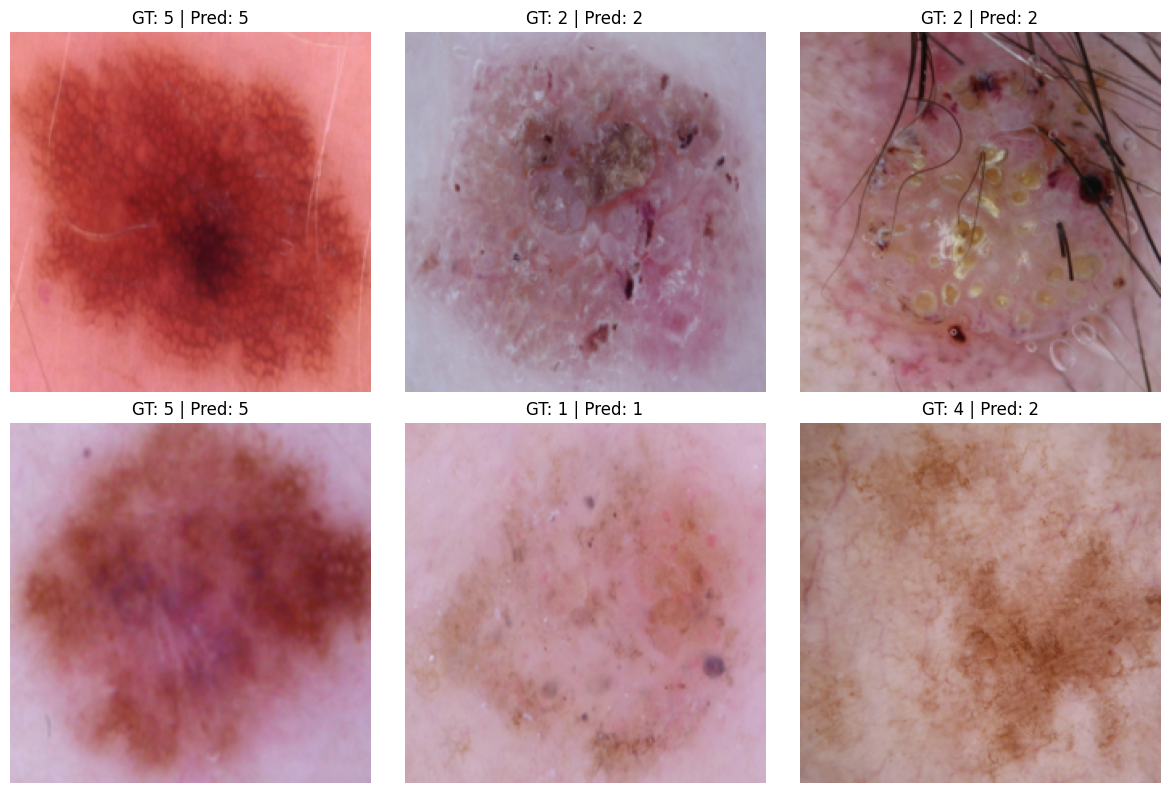

In [10]:
# visualize some predictions

indices = random.sample(range(len(val_dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, idx in zip(axes.flatten(), indices):
    image, metadata, label = val_dataset[idx]
    
    input_image = image.unsqueeze(0).to(DEVICE)
    metadata = metadata.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = model(input_image, metadata)
        pred = torch.argmax(output, dim=1).item()
    
    # Undo normalization
    img_np = image.permute(1,2,0).cpu().numpy()
    img_np = (img_np * [0.229,0.224,0.225]) + [0.485,0.456,0.406]
    img_np = np.clip(img_np, 0, 1)

    ax.imshow(img_np)
    ax.set_title(f"GT: {label.item()} | Pred: {pred}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("../")
results_path = PROJECT_ROOT / "results" / "experiments.csv"

row = {
    "model_name": "efficientnet_mask_crop",
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,

    "akiec_precision": report["0"]["precision"],
    "akiec_recall": report["0"]["recall"],
    "akiec_f1": report["0"]["f1-score"],
    "akiec_support": report["0"]["support"],

    "bcc_precision": report["1"]["precision"],
    "bcc_recall": report["1"]["recall"],
    "bcc_f1": report["1"]["f1-score"],
    "bcc_support": report["1"]["support"],

    "bkl_precision": report["2"]["precision"],
    "bkl_recall": report["2"]["recall"],
    "bkl_f1": report["2"]["f1-score"],
    "bkl_support": report["2"]["support"],

    "df_precision": report["3"]["precision"],
    "df_recall": report["3"]["recall"],
    "df_f1": report["3"]["f1-score"],
    "df_support": report["3"]["support"],

    "mel_precision": report["4"]["precision"],
    "mel_recall": report["4"]["recall"],
    "mel_f1": report["4"]["f1-score"],
    "mel_support": report["4"]["support"],

    "nv_precision": report["5"]["precision"],
    "nv_recall": report["5"]["recall"],
    "nv_f1": report["5"]["f1-score"],
    "nv_support": report["5"]["support"],

    "vasc_precision": report["6"]["precision"],
    "vasc_recall": report["6"]["recall"],
    "vasc_f1": report["6"]["f1-score"],
    "vasc_support": report["6"]["support"],
}

df = pd.DataFrame([row])

if results_path.exists():
    df.to_csv(results_path, mode="a", header=False, index=False)
else:
    df.to_csv(results_path, index=False)

print("EfficientNet Mask-Crop results saved successfully.")

EfficientNet Mask-Crop results saved successfully.
